In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
import cv2

from utils import *
from contours_extraction import *
from tracking import *

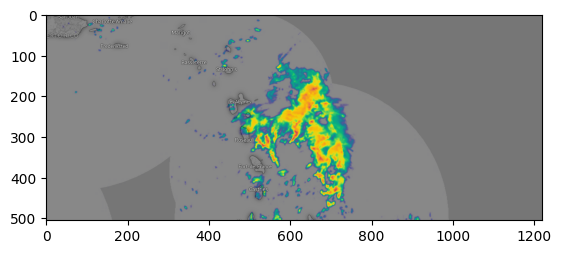

(505, 1220, 3)

In [2]:
img_path = 'data/image_old/dominica_1.png'
src_img = read_image(img_path)

plt.imshow(src_img)
plt.show()

src_img.shape

In [3]:
with open('data/legend/color_dbz.json') as f:
    list_color = json.load(f)

sorted_color = sorted({tuple(color[1]): color[0] for color in list_color}.items(), key=lambda item: item[1])
sorted_color[:3]

[((130, 130, 130), 0), ((123, 121, 132), 3), ((95, 85, 141), 8)]

Number of contours: 49


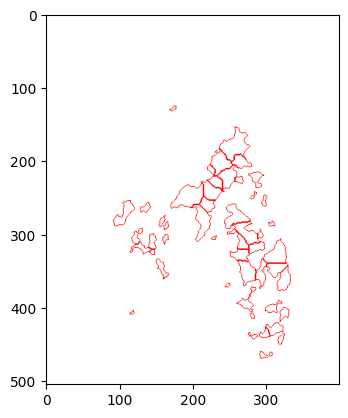

In [5]:
_, contours, _ = extract_contour_by_dbz(src_img, thresholds=[35], sorted_color=sorted_color, 
                                        subcells_check=True, distance_dbz_threshold=8)
contours = sorted([polygon for polygon in contours[0] if cv2.contourArea(polygon) >= 15], key=lambda x: cv2.contourArea(x), reverse=True)

print(f"Number of contours: {len(contours)}")

blank_img = np.ones_like(src_img, dtype=np.uint8) * 255
cv2.drawContours(blank_img, contours, -1, (255, 0, 0), 1)
plt.imshow(blank_img[:, 400:800])
plt.show()

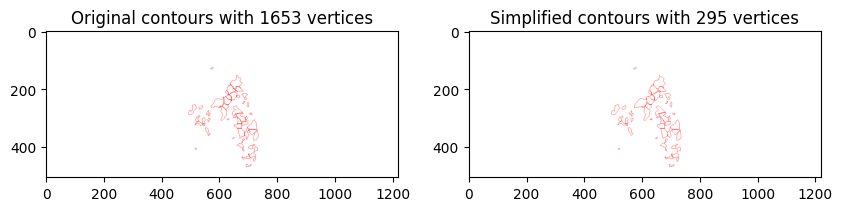

In [6]:
polygons = process_contours(contours)
simplified_contours = polygons_to_contours(polygons)

original_vertices = sum([contour.shape[0] for contour in contours])
simplified_vertices = sum([contour.shape[0] for contour in simplified_contours])

plt.figure(figsize=(10, 20))

plt.subplot(1, 2, 1)
# Left: simplified contour
blank_img = np.ones(shape=src_img.shape, dtype=np.uint8) * 255
cv2.drawContours(blank_img, contours, contourIdx=-1, color=(255, 0, 0), thickness=1)
plt.title(f"Original contours with {original_vertices} vertices")
plt.imshow(blank_img)

# Right: contour
plt.subplot(1, 2, 2)
blank_img = np.ones(shape=src_img.shape, dtype=np.uint8) * 255
cv2.drawContours(blank_img, simplified_contours  , contourIdx=-1, color=(255, 0, 0), thickness=1)
plt.title(f"Simplified contours with {simplified_vertices} vertices")
plt.imshow(blank_img)

plt.show()

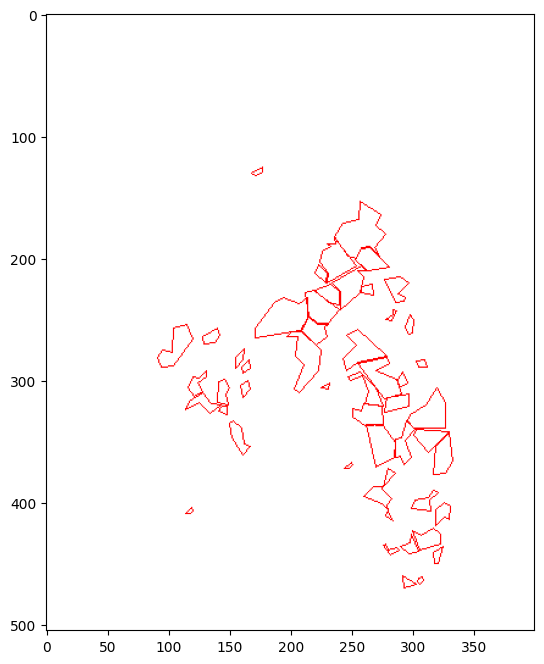

In [7]:
plt.figure(figsize=(8, 8))
plt.imshow(blank_img[:, 400:800])
plt.show()